<a href="https://colab.research.google.com/github/22f2000792/MLP-prac/blob/main/prac_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
df=load_iris(as_frame=True)

In [ ]:
df.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
df.data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
df.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

    Remove the rows if it contain NULL values.

    Train the model Using Kmeans Clustering by setting the parameter as following:

   "init": "random",    "n_init": 50,    "max_iter": 500,    "random_state": 10

In [ ]:
df.data.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


In [ ]:
from sklearn.cluster import  KMeans
km=KMeans(n_init=50,init='random',max_iter=500,random_state=10)
km.fit(df.data,df.target)

KMeans(init='random', max_iter=500, n_init=50, random_state=10)

In [ ]:
corr_data=df['data'].corr()
corr_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


In [ ]:
corr_data['petal width (cm)'].sort_values(ascending=False)

,petal width (cm)
petal width (cm),1.000000
petal length (cm),0.962865
sepal length (cm),0.817941
sepal width (cm),-0.366126


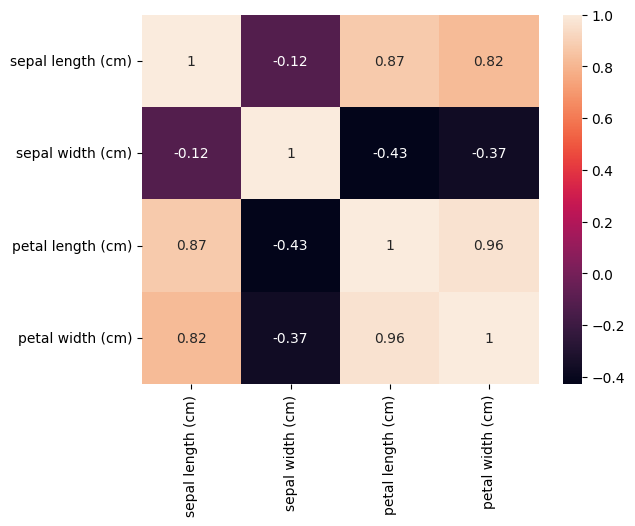

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(corr_data,annot=True)
plt.show()

In [ ]:
km.set_params(n_clusters=5)

KMeans(init='random', max_iter=500, n_clusters=5, n_init=50, random_state=10)

In [ ]:
km.fit(df.data,df.target)

KMeans(init='random', max_iter=500, n_clusters=5, n_init=50, random_state=10)

In [ ]:
km.inertia_

46.44618205128204

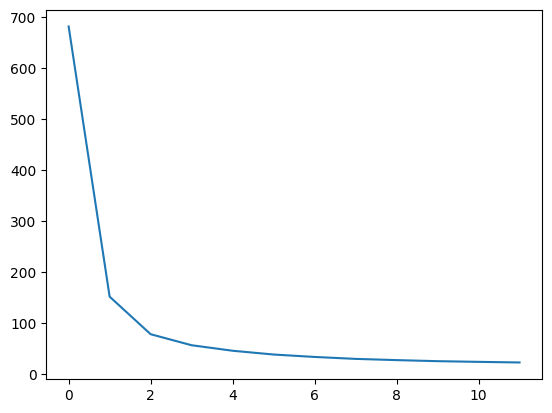

In [ ]:
inertia=[]
inertia_val=dict()
for k in range(1,13):
    km_el=KMeans(n_clusters=k,init="random", n_init= 50, max_iter=500,random_state= 10)
    km_el.fit(df.data,df.target)
    inertia_val[int(k)]=km_el.inertia_
    inertia.append(km_el.inertia_)
plt.plot(inertia)
plt.show()

In [ ]:
inertia[2]

78.851441426146

In [ ]:
pd.DataFrame.from_dict(inertia_val,orient='index')

,0
1,681.370600
2,152.347952
3,78.851441
4,57.228473
5,46.446182
6,39.039987
7,34.305815
8,30.507863
9,28.115515
10,26.030138


    Train the model using Agglomerative Clustering by setting the parameter as following

n_clusters=3,affinity='euclidean', linkage='ward'

In [ ]:
from sklearn.cluster import AgglomerativeClustering
aga=AgglomerativeClustering(n_clusters=3,metric='euclidean',linkage='ward')
aga.fit_predict(df.data)[-1]

np.int64(0)

In [ ]:
aga.n_leaves_

150

In [ ]:
km.predict(df.data)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 4, 4, 4, 3, 4, 4, 4, 3, 4, 3, 3, 4, 3, 4, 3, 4,
       4, 3, 4, 3, 4, 3, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 4, 3, 4, 4, 4,
       3, 3, 3, 4, 3, 3, 3, 3, 3, 4, 3, 3, 2, 4, 1, 2, 2, 1, 3, 1, 2, 1,
       2, 2, 2, 4, 2, 2, 2, 1, 1, 4, 2, 4, 1, 4, 2, 1, 4, 4, 2, 1, 1, 1,
       2, 4, 4, 1, 2, 2, 4, 2, 2, 2, 4, 2, 2, 2, 4, 2, 2, 4], dtype=int32)

In [ ]:
km.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'random',
 'max_iter': 500,
 'n_clusters': 5,
 'n_init': 50,
 'random_state': 10,
 'tol': 0.0001,
 'verbose': 0}